In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
from google.colab import files
uploaded = files.upload()

Saving heart.csv to heart.csv


In [4]:
df = pd.read_csv("heart.csv")

In [5]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [6]:
df.shape

(1025, 14)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [9]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [10]:
df.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


In [11]:
df.duplicated().sum()

np.int64(723)

In [12]:
df = df.drop_duplicates()

In [13]:
df.shape

(302, 14)

In [14]:
import seaborn as sns

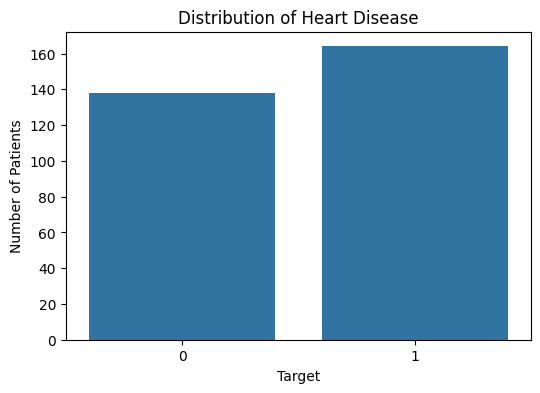

In [53]:
plt.figure(figsize=(6,4))
sns.countplot(x='target', data = df)
plt.title("Distribution of Heart Disease")
plt.xlabel("Target")
plt.ylabel("Number of Patients")
plt.savefig("heart_disease_distribution.png")
plt.show()

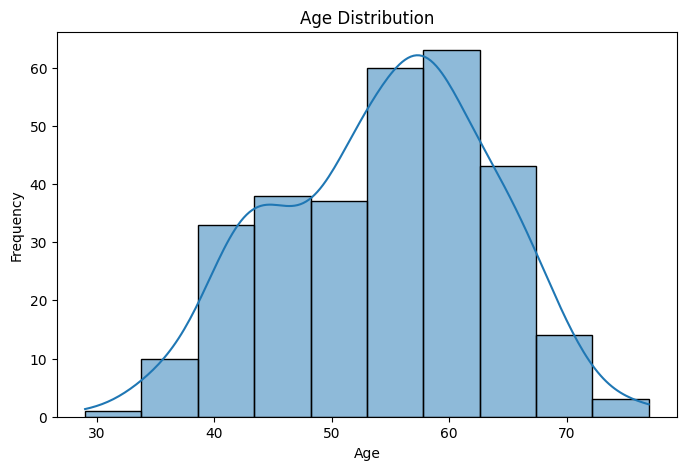

In [52]:
plt.figure(figsize=(8,5))
sns.histplot(df['age'], bins=10, kde=True)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.savefig("age_distribution.png")
plt.show()

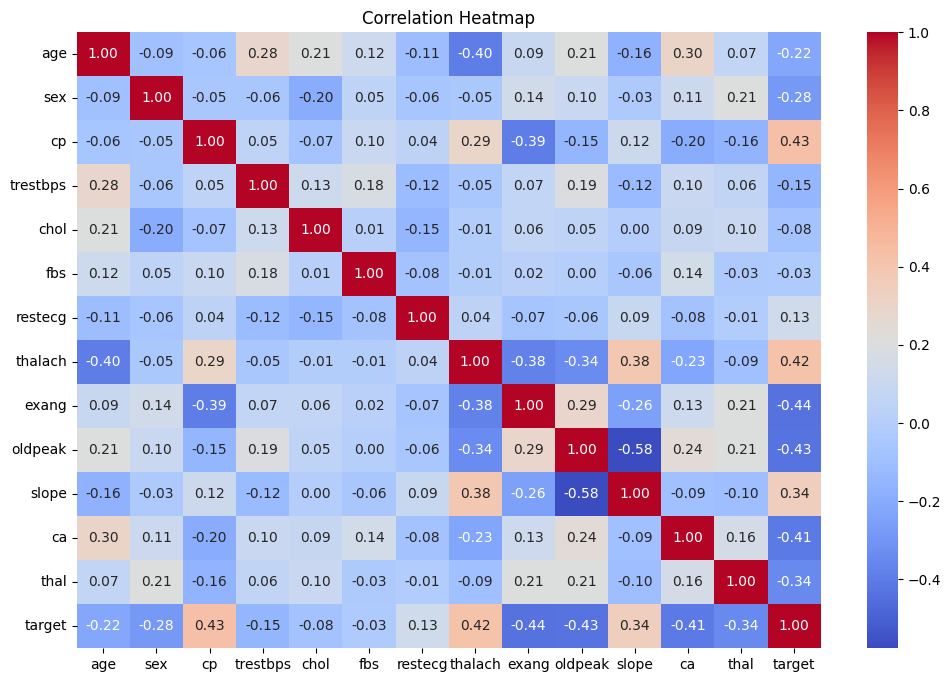

In [51]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot = True, cmap = 'coolwarm', fmt = ".2f")
plt.title("Correlation Heatmap")
plt.savefig("correlation_heatmap.png")
plt.show()

In [18]:
X = df.drop('target', axis = 1)
y= df['target']
X.shape
y.shape

(302,)

In [19]:
X.shape

(302, 13)

In [24]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size = 0.2,
    random_state=42

)

In [25]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(241, 13)
(61, 13)
(241,)
(61,)


In [26]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [27]:
X_train[:5]

array([[-0.68263287,  0.6852096 , -0.98005432, -0.40315275,  0.48628088,
        -0.42587856, -1.02487724,  0.71700677, -0.71813875, -0.44752381,
        -0.71553867, -0.70553555,  1.1181192 ],
       [ 0.40398881,  0.6852096 , -0.98005432, -0.17140603,  0.20631506,
        -0.42587856, -1.02487724, -0.83662728,  1.39248856,  1.76803161,
        -0.71553867,  1.24887901,  1.1181192 ],
       [-1.00861938, -1.45940746, -0.00404981, -0.05553267, -0.26029464,
        -0.42587856, -1.02487724,  1.10541528, -0.71813875, -0.35890159,
        -0.71553867, -0.70553555, -0.54525566],
       [-1.11728155,  0.6852096 , -0.00404981, -0.63489947, -0.52159607,
        -0.42587856,  0.86058394,  0.88963277, -0.71813875, -0.89063489,
         0.99183578, -0.70553555, -0.54525566],
       [ 0.83863748, -1.45940746, -0.98005432,  1.10320093, -0.07365076,
        -0.42587856,  0.86058394,  0.19912875,  1.39248856,  0.35007614,
        -0.71553867, -0.70553555, -0.54525566]])

In [29]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(random_state=42)
lr.fit(X_train, y_train)

LogisticRegression(random_state=42)

In [30]:
y_pred = lr.predict(X_test)

In [31]:
print(y_pred[:10])

[1 1 0 1 1 0 0 1 1 0]


In [32]:
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy: ", accuracy)

Accuracy:  0.7704918032786885


In [33]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[21 11]
 [ 3 26]]


In [34]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.88      0.66      0.75        32
           1       0.70      0.90      0.79        29

    accuracy                           0.77        61
   macro avg       0.79      0.78      0.77        61
weighted avg       0.79      0.77      0.77        61



In [35]:
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

In [36]:
from sklearn.metrics import accuracy_score
accuracy_dt = accuracy_score(y_test, y_pred_dt)
print("Decision Tree Accuracy: ", accuracy_dt)

Decision Tree Accuracy:  0.7377049180327869


In [37]:
print(classification_report(y_test, y_pred_dt))

              precision    recall  f1-score   support

           0       0.74      0.78      0.76        32
           1       0.74      0.69      0.71        29

    accuracy                           0.74        61
   macro avg       0.74      0.74      0.74        61
weighted avg       0.74      0.74      0.74        61



In [40]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

In [41]:
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print("Random Forest Accuracy", accuracy_rf)

Random Forest Accuracy 0.8360655737704918


In [42]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.89      0.78      0.83        32
           1       0.79      0.90      0.84        29

    accuracy                           0.84        61
   macro avg       0.84      0.84      0.84        61
weighted avg       0.84      0.84      0.84        61



In [43]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors = 5)
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)

In [44]:
accuracy_knn = accuracy_score(y_test, y_pred_knn)
print("KNN Accuracy: ", accuracy_knn)

KNN Accuracy:  0.7377049180327869


In [45]:
print(classification_report(y_test, y_pred_knn))

              precision    recall  f1-score   support

           0       0.79      0.69      0.73        32
           1       0.70      0.79      0.74        29

    accuracy                           0.74        61
   macro avg       0.74      0.74      0.74        61
weighted avg       0.74      0.74      0.74        61



In [46]:
import joblib
joblib.dump(rf, "random_forest_model.pkl")
print("Model Saved Successfully!")

Model Saved Successfully!


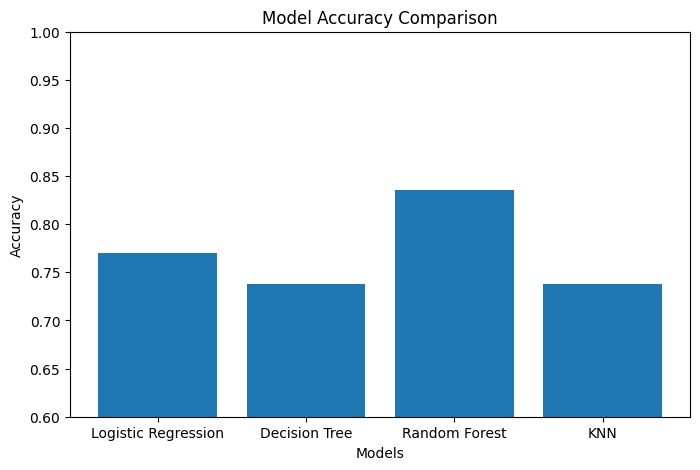

In [47]:
import matplotlib.pyplot as plt

models = ["Logistic Regression", "Decision Tree", "Random Forest", "KNN"]

accuracies = [
    accuracy,
    accuracy_dt,
    accuracy_rf,
    accuracy_knn
]

plt.figure(figsize=(8,5))
plt.bar(models, accuracies)

plt.title("Model Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")

plt.ylim(0.6,1)

plt.savefig("model_accuracy_comparison.png")

plt.show()

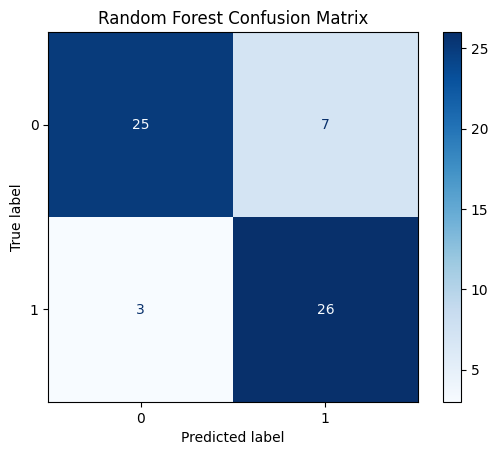

In [48]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_rf)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot(cmap="Blues")

plt.title("Random Forest Confusion Matrix")

plt.savefig("confusion_matrix.png")

plt.show()

In [54]:
import os
print(os.listdir())

['.config', 'heart.csv', 'heart_disease_distribution.png', 'correlation_heatmap.png', 'confusion_matrix.png', 'random_forest_model.pkl', 'age_distribution.png', 'model_accuracy_comparison.png', 'sample_data']
